In [ ]:
!nvidia-smi # identificazione dell'Hardware

Wed Mar 25 07:33:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
%%writefile kmeans_cuda.cu    // magic command Google Colab
#include <algorithm>          // per trovare il minimo nelle distanze o gestire i centroidi
#include <vector>             // gestisce i dati lato CPU prima di inviarli alla GPU
#include <random>             // garantisce che i test siano riproducibili
#include <iostream>           // stampare i risultati a video
#include <fstream>            // leggere/scrivere i dataset su file per i grafici
#include <limits>             // per inizializzare la distanza
#include <string>             // per il nome dei file
#include <chrono>             // misurare i tempi e calcolare quegli speedup
#include <cuda_runtime.h>     // gestione esplicita della gerarchia di memoria della GPU Tesla T4

// --- STRUTTURE DATI (CPU) ---
struct Dataset {
    size_t n_points;           // Numero totale di punti nel dataset
    size_t n_dims;             // Numero di dimensioni per ogni punto
    std::vector<float> data;   // contenitore fisico che ospita tutti i numeri

    // funzione per allocare la memoria necessaria sulla CPU (Host)
    void resize(size_t points, size_t dims) {
        n_points = points;
        n_dims = dims;
        data.resize(points * dims);  // Alloca spazio totale (punti * dimensioni)
    }

    float& at(size_t dim, size_t point) { return data[dim * n_points + point]; }
    const float& at(size_t dim, size_t point) const { return data[dim * n_points + point]; }
};

struct Centroids {
    size_t k{};                  // numero di cluster (K). inizializzato a zero
    size_t n_dims{};             // numero di dimensioni dei centroidi

    // vettore per contare quanti punti appartengono a ogni cluster
    // usato nella fase di aggiornamento (M-step) per calcolare la media
    std::vector<int> counts;

    // contenitore fisico dei dati dei centroidi
    std::vector<float> data;

    // funzione per allocare la memoria necessaria sulla CPU (Host)
    void resize(size_t clusters, size_t dims) {
        k = clusters;
        n_dims = dims;
        data.resize(clusters * dims);  // spazio totale: numero di cluster * dimensioni
        counts.resize(clusters);       // uno slot di conteggio per ogni cluster
    }

    // --- ACCESSO MEMORIA (Layout SoA) ---
    // calcola l'indice come: [dimensione * K + indice_cluster]
    // questo garantisce che tutte le coordinate X di tutti i centroidi siano contigue.
    float& at(size_t dim, size_t cluster) { return data[dim * k + cluster]; }

    // versione 'const' per la sola lettura, fondamentale durante la fase di 
    // assegnazione punti (E-step) per evitare modifiche involontarie
    const float& at(size_t dim, size_t cluster) const { return data[dim * k + cluster]; }
};

// --- GENERAZIONE DATI SINTETICI ---
// funzione che crea un dataset casuale in memoria per i test di performance
Dataset generate_synthetic_data(size_t points, size_t dims) {
    Dataset data;
    data.resize(points, dims);  // alloca il blocco di memoria contigua (points * dims)

    / inizializza il generatore di numeri casuali (Mersenne Twister)
    // il seme "42" è fisso per garantire la riproducibilità: 
    // ogni test userà gli stessi dati, rendendo i confronti tra CPU e GPU validi
    std::mt19937 gen(42);

    // definisce l'intervallo dei valori (punti nello spazio tra 0.0 e 100.0)
    std::uniform_real_distribution<float> dis(0.0f, 100.0f);

    // popola il vettore 'data' con una scansione lineare
    // grazie al layout SoA, questa operazione è molto veloce sulla CPU (ottimizzazione cache)
    for (size_t i = 0; i < points * dims; ++i) {
        data.data[i] = dis(gen);
    }
    return data; // restituisce l'oggetto Dataset pronto per essere copiato sulla GPU
}

// seleziona casualmente K punti dal dataset originale per usarli come centri iniziali
Centroids initialize_centroids(const Dataset& data, size_t k) {

    // utilizza lo stesso seed del dataset per garantire che l'esperimento 
    // sia deterministico e confrontabile tra diverse esecuzioni
    std::mt19937 gen(42);

    // genera un indice casuale compreso tra 0 e il numero totale di punti - 1
    std::uniform_int_distribution<> dis(0, data.n_points - 1);
    Centroids centroids;
    centroids.resize(k, data.n_dims);  // alloca lo spazio per i K centroidi
    for (size_t i = 0; i < k; ++i) {
        // estrae un indice di un punto esistente nel dataset
        size_t idx = dis(gen);
        // copia tutte le dimensioni del punto scelto nel nuovo centroide
        for (size_t d = 0; d < data.n_dims; ++d) {
            // nota l'uso di .at(d, i): stiamo popolando i centroidi 
            // rispettando il layout SoA per la massima efficienza futura su GPU
            centroids.at(d, i) = data.at(d, idx);
        }
    }
    return centroids;  // i centroidi iniziali sono pronti per essere inviati alla GPU
}

// --- CORE ALGORITHMS CPU ---
// funzione "inline" per eliminare l'overhead della chiamata a funzione
// calcola la distanza euclidea al quadrato tra un punto e un centroide
inline float compute_distance(const Dataset& data, size_t point_idx, const Centroids& centroids, size_t centroid_idx) {
    float dist = 0.0f;

    // cache locale delle dimensioni per evitare accessi ripetuti ai membri della struct
    const size_t n_dims = data.n_dims;
    const size_t n_points = data.n_points;
    const size_t k = centroids.k;
    // otteniamo i puntatori "raw" (grezzi) ai dati
    // questo permette al compilatore di ottimizzare i cicli for in modo più aggressivo
    const float* p_ptr = data.data.data();
    const float* c_ptr = centroids.data.data();

    // ciclo sulle dimensioni
    for (size_t d = 0; d < n_dims; ++d) {
        // accesso ai dati con layout SoA: [dimensione * totale + indice]
        // p_ptr[d * n_points + point_idx] accede alla coordinata 'd' del punto corrente
        // c_ptr[d * k + centroid_idx] accede alla coordinata 'd' del centroide corrente
        float diff = p_ptr[d * n_points + point_idx] - c_ptr[d * k + centroid_idx];

        // somma dei quadrati delle differenze (Distanza Euclidea L2)
        // non usiamo sqrt() perché per il confronto tra distanze basta il quadrato (più veloce)
        dist += diff * diff;
    }
    return dist;  // ritorna la distanza accumulata
}

void kmeans_sequential(const Dataset& data, Centroids& centroids, std::vector<int>& assignments, int max_iter) {
    // vettore temporaneo per accumulare le nuove coordinate dei centroidi durante l'aggiornamento
    std::vector<float> new_centroid_data(centroids.k * data.n_dims, 0.0f);
    for (int iter = 0; iter < max_iter; ++iter) {

        // --- FASE 1: ASSEGNAZIONE (Expectation step) ---
        // per ogni punto del dataset (fino a 10^7), cerchiamo il centroide più vicino
        for (size_t i = 0; i < data.n_points; ++i) {
            float min_dist = std::numeric_limits<float>::max();  // inizializza con il valore massimo possibile
            int best_c = 0;

            // confronta il punto 'i' con tutti i 'k' centroidi
            for (size_t j = 0; j < centroids.k; ++j) {
                float d = compute_distance(data, i, centroids, j);
                if (d < min_dist) { min_dist = d; best_c = j; }
            }
            assignments[i] = best_c;  // salva l'indice del centroide più vicino per il punto 'i'
        }

        // --- FASE 2: AGGIORNAMENTO (Maximization step) ---
        // reset dei contenitori per il calcolo delle nuove medie
        std::fill(new_centroid_data.begin(), new_centroid_data.end(), 0.0f);
        std::fill(centroids.counts.begin(), centroids.counts.end(), 0);

        // somma le coordinate di tutti i punti appartenenti a ogni cluster
        for (size_t i = 0; i < data.n_points; ++i) {
            int c = assignments[i];  // ottiene il cluster assegnato al punto
            centroids.counts[c]++;  // Incrementa il contatore di punti per quel cluster

            // somma ogni dimensione del punto nel "totalizzatore" del cluster corrispondente
            for (size_t d = 0; d < data.n_dims; ++d)
                new_centroid_data[d * centroids.k + c] += data.at(d, i);
        }
        // calcola la media finale dividendo la somma delle coordinate per il numero di punti
        for (size_t j = 0; j < centroids.k; ++j) {
            if (centroids.counts[j] > 0)  // evita la divisione per zero se un cluster è vuoto
                for (size_t d = 0; d < data.n_dims; ++d)
                    centroids.at(d, j) = new_centroid_data[d * centroids.k + j] / centroids.counts[j];
        }
    }
}

// --- KERNEL CUDA ---

// Kernel 1: Calcolo distanze e assegnazione cluster
// qualificatore __global__: indica che la funzione viene chiamata dalla CPU (Host) 
// ma viene eseguita sulla GPU (Device)
__global__ void assign_clusters_kernel(const float* data, const float* centroids, int* assignments,
                                       size_t n_points, size_t n_dims, size_t k) {
    // --- CALCOLO DELL'INDICE GLOBALE ---
    // ogni thread calcola la propria posizione univoca nella griglia
    // blockIdx.x: indice del blocco corrente
    // blockDim.x: numero di thread in un blocco (es. 256 o 512)
    // threadIdx.x: indice del thread all'interno del blocco
    int i = blockIdx.x * blockDim.x + threadIdx.x; // Indice globale del punto
    // Guard Clause: evita che i thread in eccesso accedano a memoria non allocata
    // (fondamentale se n_points non è un multiplo esatto del block size)
    if (i >= n_points) return;

    // inizializzazione della distanza minima con il valore massimo per un float
    float min_dist = 3.402823466e+38F; // Max float
    int best_c = 0;

    // --- LOOP SUI CLUSTER ---
    // ogni thread si occupa di UN SOLO PUNTO 'i' e lo confronta con tutti i 'k' cluster
    for (size_t j = 0; j < k; ++j) {
        float dist = 0.0f;
        // --- CALCOLO DISTANZA EUCLIDEA (Layout SoA) ---
        for (size_t d = 0; d < n_dims; ++d) {
            // Memory Coalescing: thread adiacenti (i, i+1, i+2...) accedono a posizioni
            // di memoria adiacenti (data[d * n_points + i])
            // questo massimizza il throughput della memoria della Tesla T4
            float diff = data[d * n_points + i] - centroids[d * k + j];
            dist += diff * diff;
        }
        // aggiornamento del cluster più vicino per il punto 'i'
        if (dist < min_dist) {
            min_dist = dist;
            best_c = j;
        }
    }
    assignments[i] = best_c;
}

// Kernel 2: Accumulo delle coordinate nei nuovi centroidi (usando atomicAdd)
// questo kernel somma le coordinate di tutti i punti assegnati a ciascun cluster
__global__ void compute_sums_kernel(const float* data, const int* assignments,
                                    float* new_centroid_data, int* counts,
                                    size_t n_points, size_t n_dims, size_t k) {
    // calcolo dell'indice globale del punto (identico al Kernel 1)
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n_points) return;

    // recupera l'indice del cluster a cui il punto 'i' è stato assegnato nel Kernel 1
    int c = assignments[i];

    // aggiorna il contatore dei punti nel cluster
    if (threadIdx.x == 0) {} // dummy per evitare warning

    // --- AGGIORNAMENTO DEL CONTATORE (COUNTS) ---
    // atomicAdd è fondamentale: impedisce la "Race Condition"
    // se due thread aggiornano lo stesso cluster 'c' nello stesso istante, 
    // l'operazione viene messa in coda e il conteggio finale sarà corretto
    atomicAdd(&counts[c], 1);

    // --- SOMMA ATOMICA DELLE COORDINATE ---
    // Per ogni dimensione del punto corrente:
    for (size_t d = 0; d < n_dims; ++d) {
        // somma la coordinata 'd' del punto 'i' al totalizzatore del cluster 'c'
        // anche qui usiamo atomicAdd perché migliaia di punti appartengono allo stesso cluster
        // nota il layout SoA: data[d * n_points + i] garantisce il coalescing della memoria
        atomicAdd(&new_centroid_data[d * k + c], data[d * n_points + i]);
    }
}

// Kernel 3: Calcolo della media per riposizionare i centroidi
// questo kernel calcola la media finale dividendo la somma delle coordinate 
// per il numero di punti assegnati a ciascun cluster
__global__ void update_centroids_kernel(float* centroids, const float* new_centroid_data,
                                        const int* counts, size_t n_dims, size_t k) {
    
    // --- INDICE DEL CENTROIDE ---
    // qui l'indice 'j' non rappresenta un punto, ma un CLUSTER (da 0 a K-1)
    // poiché K è solitamente piccolo (es. 128), questo kernel usa pochissimi thread
    // rispetto ai precedenti, ma è fondamentale per completare l'iterazione
    int j = blockIdx.x * blockDim.x + threadIdx.x; // Indice del centroide
    // Guard Clause: termina i thread che superano il numero di cluster K
    if (j >= k) return;

    // legge dalla memoria globale quanti punti sono stati assegnati al cluster 'j'
    int count = counts[j];
    // controllo di sicurezza: aggiorna il centroide solo se contiene almeno un punto
    // se il cluster è vuoto (count == 0), il centroide rimane nella posizione precedente
    // per evitare una divisione per zero che genererebbe valori NaN (Not a Number)
    if (count > 0) {
        // ciclo sulle dimensioni per ricalcolare la posizione media del centroide
        for (size_t d = 0; d < n_dims; ++d) {
            // centroids[d * k + j]: posizione finale nel layout SoA
            // new_centroid_data[d * k + j]: la somma accumulata dal Kernel 2
            centroids[d * k + j] = new_centroid_data[d * k + j] / count;
        }
    }
}

// Funzione wrapper per l'esecuzione CUDA

// calcola quanti byte occupano le strutture dati in memoria RAM
// fondamentale per sapere quanto spazio "chiedere" alla GPU
void kmeans_cuda(const Dataset& host_data, Centroids& host_centroids, std::vector<int>& host_assignments, int max_iter, int block_size) {

    // 1. Calcolo del Peso dei Dati
    size_t points_bytes = host_data.data.size() * sizeof(float);            // spazio per 10^7 punti
    size_t centroids_bytes = host_centroids.data.size() * sizeof(float);    // spazio per i K centroidi
    size_t assignments_bytes = host_data.n_points * sizeof(int);            // spazio per le etichette dei cluster
    size_t counts_bytes = host_centroids.k * sizeof(int);                   // contatori per ogni cluster

    // 2. Allocazione e Trasferimento (da Host a Device)
    // Allocazione memoria su Device (GPU)
    float *d_data, *d_centroids, *d_new_centroids;
    int *d_assignments, *d_counts;
    // riserva spazio fisico nella VRAM della Tesla T4 (Memoria Globale)
    // d_ davanti ai nomi indica "Device" (GPU)
    cudaMalloc(&d_data, points_bytes);
    cudaMalloc(&d_centroids, centroids_bytes);
    cudaMalloc(&d_new_centroids, centroids_bytes);
    cudaMalloc(&d_assignments, assignments_bytes);
    cudaMalloc(&d_counts, counts_bytes);

    // Copia dati da Host a Device
    // copia il dataset e i centroidi iniziali dalla RAM della CPU alla VRAM della GPU
    // questo è un passaggio costoso: ecco perché facciamo tutte le iterazioni dentro la GPU
    cudaMemcpy(d_data, host_data.data.data(), points_bytes, cudaMemcpyHostToDevice);
    cudaMemcpy(d_centroids, host_centroids.data.data(), centroids_bytes, cudaMemcpyHostToDevice);

    // 3. Configurazione della Griglia
    // calcola quanti blocchi servono per coprire tutti i punti
    // se block_size è 256, dividiamo i 10 milioni di punti in blocchi da 256 thread l'uno
    int grid_size_points = (host_data.n_points + block_size - 1) / block_size;
    int grid_size_clusters = (host_centroids.k + block_size - 1) / block_size;

    // 4. Il Ciclo di Calcolo (Iterazioni K-Means)
    for (int iter = 0; iter < max_iter; ++iter) {
        // Step 1: Assegnazione
        // LANCIO KERNEL 1: Ogni thread calcola la distanza per un punto
        assign_clusters_kernel<<<grid_size_points, block_size>>>(d_data, d_centroids, d_assignments, host_data.n_points, host_data.n_dims, host_centroids.k);

        // Step 2: Azzera i centroidi temporanei e i contatori
        // PULIZIA: Azzera la memoria dei centroidi temporanei prima di sommare i nuovi valori
        cudaMemset(d_new_centroids, 0, centroids_bytes);
        cudaMemset(d_counts, 0, counts_bytes);

        // Step 3: Accumulo (Sommatoria coord e conteggio)
        // LANCIO KERNEL 2: Accumulo atomico delle posizioni dei nuovi centroidi
        compute_sums_kernel<<<grid_size_points, block_size>>>(d_data, d_assignments, d_new_centroids, d_counts, host_data.n_points, host_data.n_dims, host_centroids.k);

        // Step 4: Calcolo media
        // LANCIO KERNEL 3: Calcola la media finale (solo K thread attivi)
        update_centroids_kernel<<<grid_size_clusters, block_size>>>(d_centroids, d_new_centroids, d_counts, host_data.n_dims, host_centroids.k);
    }

    // Sincronizza e copia risultati finali su Host
    // aspetta che la GPU abbia finito tutti i calcoli prima di leggere i risultati
    cudaDeviceSynchronize();
    // copia i risultati finali (assegnazioni e centroidi ottimizzati) indietro nella CPU
    cudaMemcpy(host_assignments.data(), d_assignments, assignments_bytes, cudaMemcpyDeviceToHost);
    cudaMemcpy(host_centroids.data.data(), d_centroids, centroids_bytes, cudaMemcpyDeviceToHost);

    // Pulizia memoria VRAM
    // LIBERA LA MEMORIA: Fondamentale per non causare "Memory Leak" sulla GPU
    cudaFree(d_data);
    cudaFree(d_centroids);
    cudaFree(d_new_centroids);
    cudaFree(d_assignments);
    cudaFree(d_counts);
}

// Funzione helper per il cronometro
// calcola il tempo trascorso in millisecondi tra un punto di inizio e il momento attuale
double get_time_ms(std::chrono::high_resolution_clock::time_point start) {

    // cattura l'istante temporale esatto nel momento in cui la funzione viene chiamata
    // viene usato 'high_resolution_clock', il cronometro più preciso disponibile in C++
    auto end = std::chrono::high_resolution_clock::now();

    // calcola la differenza (duration) tra il tempo finale (end) e quello iniziale (start)
    // lo converte esplicitamente in millisecondi (std::milli) usando valori decimali (double)
    // .count() estrae il valore numerico puro dalla struttura temporale
    return std::chrono::duration<double, std::milli>(end - start).count();
}

// --- MAIN ---
int main() {
    // Sostituiamo i core fisici (OpenMP) con le configurazioni di block_size (CUDA)
    // definiamo diverse taglie di "Block Size". 
    // serve a trovare il punto di massima efficienza della Tesla T4
    std::vector<int> block_sizes = {32, 64, 128, 256, 512, 1024};
    int max_iter = 5; // numero di iterazioni per rendere il test significativo ma veloce

    // 1. MATRICE: SPEEDUP vs POINTS
    {
        std::vector<size_t> test_points = {1000, 10000, 100000, 1000000, 10000000};
        size_t d = 8; size_t k = 16;
        std::ofstream csv("table_points_blocks.csv");
        csv << "Points,B32,B64,B128,B256,B512,B1024\n";

        // per ogni numero di punti (N)
        for (size_t N : test_points) {
            Dataset data = generate_synthetic_data(N, d); // genera i dati
            std::vector<int> assign(N);
            Centroids c_seq = initialize_centroids(data, k);

            // misura il tempo della versione sequenziale (CPU)
            auto t0 = std::chrono::high_resolution_clock::now();
            kmeans_sequential(data, c_seq, assign, max_iter);
            double seq_ms = get_time_ms(t0); // questo è il nostro termine di paragone

            csv << N; // scrive il numero di punti nel CSV
            for (int B : block_sizes) {
                Centroids c_par = initialize_centroids(data, k);

                // misura il tempo della versione parallela (GPU) con block size B
                auto pt0 = std::chrono::high_resolution_clock::now();
                kmeans_cuda(data, c_par, assign, max_iter, B);
                double par_ms = get_time_ms(pt0);

                // calcola lo SPEEDUP: (Tempo CPU / Tempo GPU)
                double speedup = seq_ms / par_ms;
                csv << "," << speedup;  // aggiunge il dato alla riga del CSV
            }
            csv << "\n";
            std::cout << "Finito Points N=" << N << std::endl;
        }
    }

    // 2. MATRICE: TEMPI vs DIMENSIONS (per il grafico)
    {
        std::vector<size_t> test_dims = {2, 4, 8, 16, 32, 64, 128, 256};
        size_t N = 1000000;
        size_t k = 16;
        int best_block_size = 256; // Usiamo il blocco più stabile per il grafico

        std::ofstream csv_times("times_dims.csv");
        csv_times << "Dim,T_seq,T_cuda\n";

        for (size_t D : test_dims) {
            Dataset data = generate_synthetic_data(N, D);
            std::vector<int> assign(N);
            Centroids c_seq = initialize_centroids(data, k);

            // Tempo Sequenziale
            auto t0 = std::chrono::high_resolution_clock::now();
            kmeans_sequential(data, c_seq, assign, max_iter);
            double seq_ms = get_time_ms(t0);

            // Tempo CUDA
            Centroids c_par = initialize_centroids(data, k);
            auto pt0 = std::chrono::high_resolution_clock::now();
            kmeans_cuda(data, c_par, assign, max_iter, best_block_size);
            double par_ms = get_time_ms(pt0);

            // Salviamo i tempi grezzi invece dello speedup
            csv_times << D << "," << seq_ms << "," << par_ms << "\n";
            std::cout << "D=" << D << " | Seq: " << seq_ms << "ms | GPU: " << par_ms << "ms" << std::endl;
        }
        csv_times.close();
    }

    // 3. MATRICE: SPEEDUP vs CLUSTERS
    {
        std::vector<size_t> test_ks = {2, 4, 8, 16, 32, 64, 128};
        size_t N = 1000000; size_t d = 8;
        std::ofstream csv("table_clusters_blocks.csv");
        csv << "Clusters,B32,B64,B128,B256,B512,B1024\n";

        for (size_t K : test_ks) {
            Dataset data = generate_synthetic_data(N, d);
            std::vector<int> assign(N);
            Centroids c_seq = initialize_centroids(data, K);

            auto t0 = std::chrono::high_resolution_clock::now();
            kmeans_sequential(data, c_seq, assign, max_iter);
            double seq_ms = get_time_ms(t0);

            csv << K;
            for (int B : block_sizes) {
                Centroids c_par = initialize_centroids(data, K);

                auto pt0 = std::chrono::high_resolution_clock::now();
                kmeans_cuda(data, c_par, assign, max_iter, B);
                double par_ms = get_time_ms(pt0);

                double speedup = seq_ms / par_ms;
                csv << "," << speedup;
            }
            csv << "\n";
            std::cout << "Finito Clusters K=" << K << std::endl;
        }
    }

    std::cout << "Tutti i file CSV sono stati generati con successo in CUDA." << std::endl;
    return 0;
}

Overwriting kmeans_cuda.cu


In [ ]:
!nvcc -O3 kmeans_cuda.cu -o kmeans_cuda

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


In [ ]:
!ls -l

total 1048
-rwxr-xr-x 1 root root 1038448 Mar 25 08:09 kmeans_cuda
-rw-r--r-- 1 root root   12594 Mar 25 08:08 kmeans_cuda.cu
drwxr-xr-x 1 root root    4096 Mar 23 13:34 sample_data
-rw-r--r-- 1 root root     385 Mar 25 07:44 table_clusters_blocks.csv
-rw-r--r-- 1 root root     392 Mar 25 07:44 table_dims_blocks.csv
-rw-r--r-- 1 root root     312 Mar 25 07:43 table_points_blocks.csv


In [ ]:
!./kmeans_cuda

Finito Points N=1000
Finito Points N=10000
Finito Points N=100000
Finito Points N=1000000
Finito Points N=10000000
D=2 | Seq: 221.77ms | GPU: 7.69183ms
D=4 | Seq: 361.203ms | GPU: 12.7ms
D=8 | Seq: 609.94ms | GPU: 17.4319ms
D=16 | Seq: 1154.41ms | GPU: 47.6272ms
D=32 | Seq: 2601.04ms | GPU: 91.979ms
D=64 | Seq: 6595.6ms | GPU: 171.376ms
D=128 | Seq: 14956.2ms | GPU: 324.144ms
D=256 | Seq: 31232ms | GPU: 633.92ms
Finito Clusters K=2
Finito Clusters K=4
Finito Clusters K=8
Finito Clusters K=16
Finito Clusters K=32
Finito Clusters K=64
Finito Clusters K=128
Tutti i file CSV sono stati generati con successo in CUDA.


In [ ]:
from google.colab import files

# Scarica i tre file generati dal tuo codice C++
files.download('table_points_blocks.csv')
files.download('table_dims_blocks.csv')
files.download('table_clusters_blocks.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

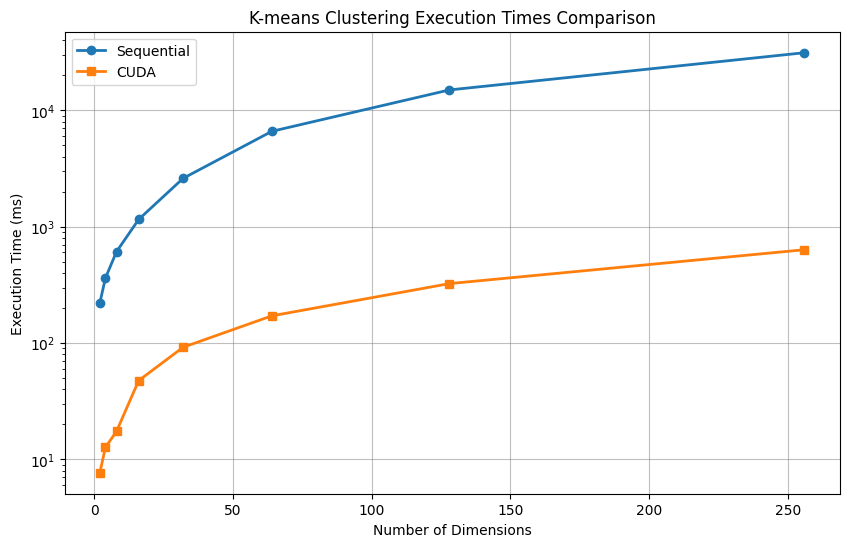

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Carica i dati
df = pd.read_csv('times_dims.csv')

plt.figure(figsize=(10, 6))

# Plot dei dati
plt.plot(df['Dim'], df['T_seq'], marker='o', color='#1f77b4', label='Sequential', linewidth=2)
plt.plot(df['Dim'], df['T_cuda'], marker='s', color='#ff7f0e', label='CUDA', linewidth=2)

# SCALA E GRIGLIA
plt.yscale('log')
# Opzionale: attiva log anche su X se vuoi simmetria totale dei quadratini
# plt.xscale('log')

# Pulizia della griglia: mostriamo solo le linee principali
plt.grid(True, which="major", ls="-", linewidth=0.8, color='gray', alpha=0.5)
# Riduciamo l'impatto delle linee secondarie (quelle fitte che non ti piacciono)
plt.grid(True, which="minor", ls=":", linewidth=0.4, color='gray', alpha=0)

plt.title('K-means Clustering Execution Times Comparison')
plt.xlabel('Number of Dimensions')
plt.ylabel('Execution Time (ms)')
plt.legend()

plt.show()